## 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from sklearn.decomposition import PCA

## 2. Model Definition

`SimpleDPN`: a two-layer network with no bias terms. The hidden layer is
followed by a polynomial activation $x \mapsto x^p$ (order `poly_order`)
instead of a standard nonlinearity like ReLU.

All weight-initialization and lattice/plotting helpers used elsewhere in the
notebook live here too, so this section is the single place to look for
what the model actually does.

In [2]:
class PolynomialActivation(nn.Module):
    """Elementwise activation x -> x^order."""

    def __init__(self, order):
        super().__init__()
        self.order = order

    def forward(self, x):
        return torch.pow(x, self.order)


class SimpleDPN(nn.Module):
    """Shallow polynomial neural network: Linear -> x^p -> Linear, no bias."""

    def __init__(self, input_dim, hidden_dim, output_dim, poly_order):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.poly_order = poly_order

        self.fc1 = nn.Linear(input_dim, hidden_dim, bias=False)
        self.fc2 = nn.Linear(hidden_dim, output_dim, bias=False)
        self.poly_act = PolynomialActivation(poly_order)

    def forward(self, x):
        x = self.poly_act(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
def initialize_weights(model):
    """Xavier-normal init for every nn.Linear layer in the model."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                m.bias.data.fill_(0.01)


def custom_initialize_weights(model, custom_weights, custom_biases=None):
    """Overwrite each nn.Linear layer weight (and optionally bias) in order."""
    i = 0
    for m in model.modules():
        if isinstance(m, nn.Linear):
            m.weight.data = custom_weights[i]
            if m.bias is not None and custom_biases is not None:
                m.bias.data = custom_biases[i]
            i += 1


def print_model_weights(model):
    print("\nModel Weights:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name}:\n{param.data.cpu().numpy()}\n")

In [4]:
def generate_lattice(n, dimensions, step_sizes, marker=None, dtype=np.float64):
    """Regular n-dimensional lattice, offset by `marker` if given."""
    if len(dimensions) != n or len(step_sizes) != n:
        raise ValueError(
            f"Length of dimensions ({len(dimensions)}) and step_sizes "
            f"({len(step_sizes)}) must be equal to n ({n})"
        )
    if marker is not None and len(marker) != n:
        raise ValueError(
            f"Length of marker ({len(marker)}) must be equal to the number of dimensions ({n})"
        )

    grids = np.meshgrid(
        *[np.arange(0, dim + step, step, dtype=dtype) for dim, step in zip(dimensions, step_sizes)],
        indexing="ij",
    )
    lattice = np.vstack([grid.ravel() for grid in grids]).T.astype(dtype)

    if marker is not None:
        lattice += np.array(marker, dtype=dtype)

    return lattice

In [5]:
def plot_data(data, colors=None, save_file=False, filename="plot.html"):
    """
    Interactive 2D or 3D scatter plot (plotly) with color values shown on hover.

    Parameters:
        data (tuple): (x, y) for 2D or (x, y, z) for 3D scatter.
        colors (array-like): color values for the points.
        save_file (bool): if True, saves the plot as an HTML file.
        filename (str): file name used when save_file is True.
    """
    if colors is None:
        colors = np.array([0] * len(data[0]))

    color_labels = [f"Color: {c:.3f}" for c in colors]

    if len(data) == 2:
        x, y = data
        fig = go.Figure(
            data=[go.Scatter(
                x=x, y=y,
                mode="markers",
                marker=dict(size=6, color=colors, colorscale="jet", opacity=1),
                text=color_labels,
                hoverinfo="text",
            )]
        )
        fig.update_layout(
            xaxis=dict(scaleanchor="y"),
            yaxis=dict(scaleanchor="x"),
            title="2D Scatter Plot with Hover Color Values",
        )
    elif len(data) == 3:
        x, y, z = data
        fig = go.Figure(
            data=[go.Scatter3d(
                x=x, y=y, z=z,
                mode="markers",
                marker=dict(size=6, color=colors, colorscale="jet", opacity=1),
                text=color_labels,
                hoverinfo="text",
            )]
        )
        fig.update_layout(scene=dict(aspectmode="data"), title="3D Scatter Plot with Hover Color Values")
    else:
        raise ValueError("Data must be a tuple containing 2D (x, y) or 3D (x, y, z) points.")

    if save_file:
        if not isinstance(filename, str):
            raise ValueError(f"Expected filename as a string, but got {type(filename)}: {filename}")
        fig.write_html(filename)
        print(f"Interactive plot saved as {filename}")

    fig.show()


def plot_lattice(X, w):
    """Matplotlib 3D scatter of a lattice X colored by value w."""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=w, cmap="jet")
    cbar = plt.colorbar(sc, aspect=30)
    cbar.set_label("w value")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.title("3D Lattice Plot")
    plt.show()


def plot_loss_history(loss_history, title="Training Loss per Epoch on a Logarithmic Scale"):
    """Single training run's loss curve, log-scaled y-axis."""
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history, label="Training loss")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_sorted_loss(loss_val, title="Sorted Loss Curve", xlabel="Sample Index", ylabel="Loss"):
    """Publication-style scatter of loss values sorted from smallest to largest."""
    sorted_loss = np.sort(loss_val)
    plt.figure(figsize=(6, 4))
    plt.scatter(np.arange(len(sorted_loss)), sorted_loss, s=10, color="black")
    plt.title(title, fontsize=12)
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()

## 3. Training, Test, and Validation Data

Architecture and target function are fixed here: `d = (3, 3, 1)`, target
$f(x,y,z) = x^2 + y^2 - z^2$ (cone). Training and test sets are both regular
lattices over the same cube, just at different resolutions (`step_sizes`).

In [ ]:
# --- Architecture and training config ---
d0 = 3       # input dimension
d1 = 3       # hidden dimension
order = 2    # polynomial activation order
epochs = 10000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def f_target(X, Y, Z):
    """Target homogeneous polynomial: a cone."""
    return X**2 + Y**2 - Z**2


def make_lattice_dataset(n, dim, step, seed=None, noise_level=0.0):
    """
    Build a (X, w) dataset on a regular n-D lattice over [-dim, dim]^n at
    resolution `step`, with target values w = f_target(x, y, z) (+ optional noise).
    Returns torch tensors X (float32, shape [N, n]) and w (float32, shape [N, 1]).
    """
    if seed is not None:
        np.random.seed(seed)

    dimensions = [2 * dim] * n
    step_sizes = [step] * n
    marker = [-dim] * n

    lattice = generate_lattice(n, dimensions, step_sizes, marker)
    noise = np.random.normal(0, noise_level, len(lattice)) if noise_level else 0.0

    x, y, z = lattice[:, 0], lattice[:, 1], lattice[:, 2]
    w = f_target(x, y, z) + noise

    X_tensor = torch.tensor(lattice, dtype=torch.float32)
    w_tensor = torch.tensor(w.reshape(-1, 1), dtype=torch.float32)
    return X_tensor, w_tensor

In [7]:
# --- Build the training set ---
X_train, w_train = make_lattice_dataset(n=d0, dim=2, step=0.5, seed=0, noise_level=0)

plot_data(X_train[:, :3].numpy().T, w_train.numpy().T[0])
# plot_lattice(X_train.numpy(), w_train.numpy().T[0])

The cone shape -> represents $x^2 + y^2 - z^2$.

In [8]:
# --- Build the test set (finer resolution than training) ---
X_test, w_test = make_lattice_dataset(n=d0, dim=2, step=0.2, seed=None, noise_level=0)

## 4. Train One Neural Network

Trains a single `SimpleDPN`, plots its loss curve, and evaluates it on the
test set.

In [9]:
def train_one_network(model, X, w, epochs, lr=0.001, log_every=1000, verbose=True):
    """
    Trains `model` in place with Adam + MSE loss on (X, w).
    Returns the per-epoch loss history (list of floats).
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    loss_history = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, w)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if verbose and (epoch + 1) % log_every == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

    return loss_history


def evaluate_network(model, X, w):
    """Runs `model` in eval mode on (X, w) and returns (test_loss, predictions)."""
    criterion = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        output = model(X)
        loss = criterion(output, w)
    return loss.item(), output


Model Weights:
fc1.weight:
[[ 0.6943589   0.28726548 -0.7205462 ]
 [ 0.28908312  0.81325513  0.11931253]
 [-0.2934274   0.02239057 -0.7545345 ]]

fc2.weight:
[[0.97313005 0.46458724 0.03248363]]

Epoch [1000/10000], Loss: 0.0047
Epoch [2000/10000], Loss: 0.0000
Epoch [3000/10000], Loss: 0.0000
Epoch [4000/10000], Loss: 0.0000
Epoch [5000/10000], Loss: 0.0000
Epoch [6000/10000], Loss: 0.0000
Epoch [7000/10000], Loss: 0.0000
Epoch [8000/10000], Loss: 0.0000
Epoch [9000/10000], Loss: 0.0000
Epoch [10000/10000], Loss: 0.0000

Model Weights:
fc1.weight:
[[ 1.0894824   0.1516448  -0.37498257]
 [-0.13111888  1.1397771  -0.07997235]
 [ 0.46894297  0.1536275  -1.4246954 ]]

fc2.weight:
[[ 0.93514955  0.7634485  -0.55984634]]



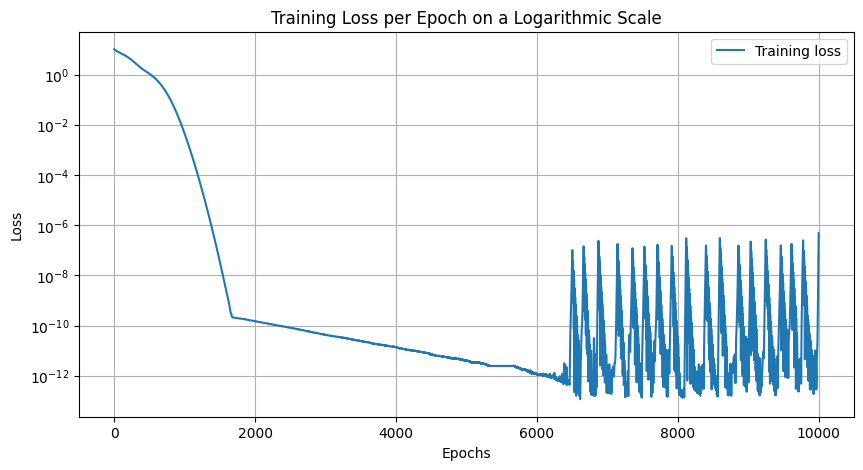

In [10]:
# --- Initialize and train a single network ---
dpn = SimpleDPN(input_dim=d0, hidden_dim=d1, output_dim=1, poly_order=order)
initialize_weights(dpn)
print_model_weights(dpn)

train_loss_history = train_one_network(dpn, X_train, w_train, epochs=epochs)

print_model_weights(dpn)
plot_loss_history(train_loss_history)

In [11]:
# --- Evaluate on the test set ---
test_loss, test_output = evaluate_network(dpn, X_test, w_test)
print(f"Test Loss: {test_loss:.4f}")

X_test_np = X_test.cpu().detach().numpy()
test_output_np = test_output.cpu().detach().numpy()
colors = np.around(test_output_np.T[0], decimals=2)
plot_data(X_test_np[:, :3].T, colors)

Test Loss: 0.0000


## 5. Train N Neural Networks and Save Parameters

Repeats the single-network training run `N` times with fresh random
initializations, saving each run's initial weights, final weights, and loss
curve to disk. These files are consolidated and re-loaded in Section 6.

In [12]:
# --- Paths: everything lives under one configurable run directory ---
RUN_DIR = os.path.join(".", "dpnn_runs")             # change this to point elsewhere
RAW_DIR = os.path.join(RUN_DIR, "final_loss_train")  # raw per-run .npy files
os.makedirs(RAW_DIR, exist_ok=True)

In [13]:
def get_file_count(directory):
    """Number of files (not directories) directly inside `directory`."""
    return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])


def save_weights(model, save_dir, tag, run_index):
    """
    Saves each nn.Linear layer's weight+bias as a single .npy file
    (bias appended as an extra column, plus a [0,...,0,1] sentinel row),
    named '{run_index}_{layer_name}_{tag}.npy'.
    """
    layer_weights_biases = {}
    for name, param in model.named_parameters():
        if "weight" in name or "bias" in name:
            layer_name = name.split(".")[0]
            layer_weights_biases.setdefault(layer_name, {"weight": None, "bias": None})
            if "weight" in name:
                layer_weights_biases[layer_name]["weight"] = param.data.cpu().numpy()
            elif "bias" in name:
                layer_weights_biases[layer_name]["bias"] = param.data.cpu().numpy()

    for layer_name, params in layer_weights_biases.items():
        weight = params["weight"]
        bias = params["bias"]
        if bias is None:
            bias = np.zeros((weight.shape[0],))
        combined = np.column_stack((weight, bias))
        sentinel_row = np.zeros((1, combined.shape[1]))
        sentinel_row[0, -1] = 1
        combined = np.vstack((combined, sentinel_row))

        filename = os.path.join(save_dir, f"{run_index}_{layer_name}_{tag}.npy")
        np.save(filename, combined)

In [14]:
def train_n_networks(N, input_dim, hidden_dim, output_dim, poly_order,
                      X, w, epochs, save_dir, log_every=100):
    """
    Trains N independently-initialized SimpleDPN networks on (X, w),
    saving initial weights, final weights, and a subsampled loss curve
    (every `log_every` epochs) for each run.
    """
    model = SimpleDPN(input_dim, hidden_dim, output_dim, poly_order)

    for run_index in range(N):
        initialize_weights(model)
        save_weights(model, save_dir, "initial", run_index)

        loss_history = train_one_network(model, X, w, epochs=epochs, verbose=False)
        subsampled_loss = loss_history[log_every - 1::log_every]

        print(f"{run_index}: {loss_history[-1]:.6f} final loss")

        np.save(os.path.join(save_dir, f"{run_index}_loss_values.npy"), subsampled_loss)
        save_weights(model, save_dir, "final", run_index)

In [15]:
# --- Run the N-network sweep ---
N = 40  # how many neural networks to train

train_n_networks(
    N=N,
    input_dim=d0, hidden_dim=d1, output_dim=1, poly_order=order,
    X=X_train, w=w_train,
    epochs=epochs,
    save_dir=RAW_DIR,
)

0: 0.000000 final loss
1: 2.911051 final loss
2: 0.000000 final loss
3: 2.911051 final loss
4: 0.000000 final loss
5: 2.911051 final loss
6: 2.911051 final loss
7: 0.000000 final loss
8: 2.911051 final loss
9: 0.000000 final loss
10: 0.000000 final loss
11: 0.000000 final loss
12: 0.000000 final loss
13: 2.911051 final loss
14: 0.000000 final loss
15: 0.000000 final loss
16: 2.911051 final loss
17: 2.911051 final loss
18: 2.911051 final loss
19: 2.911051 final loss
20: 2.911051 final loss
21: 0.000000 final loss
22: 2.911051 final loss
23: 0.000000 final loss
24: 0.000000 final loss
25: 0.000000 final loss
26: 2.911051 final loss
27: 0.000000 final loss
28: 0.000000 final loss
29: 2.911051 final loss
30: 0.000000 final loss
31: 0.000000 final loss
32: 0.000000 final loss
33: 0.000000 final loss
34: 0.000000 final loss
35: 0.000000 final loss
36: 0.000000 final loss
37: 2.911051 final loss
38: 0.000000 final loss
39: 0.000000 final loss


## 6. Save and Work with Neural Network Parameters

Loads the raw per-run `.npy` files written in Section 5, filters runs by
final loss (`min_loss < final_loss < max_loss`), strips the bias
column/sentinel row back off, and writes consolidated arrays:

- `W1_start.npy`, `W2_start.npy`: per-layer weight matrices at initialization
- `W1_finish.npy`, `W2_finish.npy`: per-layer weight matrices after training
- `weights_start.npy`, `weights_finish.npy`: each run flattened to one row
- `loss_start.npy`, `loss_finish.npy`: first and last loss value per run

This section only needs to be re-run when the raw files in `RAW_DIR` change.

In [16]:
def load_loss_curves(save_dir, count, min_loss=-1, max_loss=1_000_000):
    """
    Loads each run's saved loss curve and keeps the (first, last) loss
    values for runs whose final loss falls in (min_loss, max_loss).
    """
    loss_start, loss_finish = [], []
    for i in range(count):
        loss = np.load(os.path.join(save_dir, f"{i}_loss_values.npy"))
        if min_loss < loss[-1] < max_loss:
            loss_start.append(loss[0])
            loss_finish.append(loss[-1])
    return np.array(loss_start), np.array(loss_finish)


def load_consolidated_weights(save_dir, count, tag, min_loss=-1, max_loss=1_000_000):
    """
    Loads each run's fc1/fc2 weight files for the given tag ('initial' or
    'final'), keeping only runs whose final loss falls in (min_loss, max_loss).
    Strips the bias column and sentinel row added by save_weights.

    Returns:
        W1s: list of fc1 weight matrices (one per kept run)
        W2s: list of fc2 weight matrices (one per kept run)
        flattened: array of shape (n_kept_runs, fc1_size + fc2_size), each
                   run's fc1 and fc2 weights concatenated into one row
    """
    W1s, W2s, flattened = [], [], []
    for i in range(count):
        matrix1 = np.load(os.path.join(save_dir, f"{i}_fc1_{tag}.npy"))
        matrix2 = np.load(os.path.join(save_dir, f"{i}_fc2_{tag}.npy"))
        loss = np.load(os.path.join(save_dir, f"{i}_loss_values.npy"))

        if min_loss < loss[-1] < max_loss:
            w1 = matrix1[:-1, :-1]  # drop sentinel row, bias column
            w2 = matrix2[:-1, :-1]
            W1s.append(w1)
            W2s.append(w2)
            flattened.append(np.hstack((w1.reshape(-1), w2.reshape(-1))))

    return W1s, W2s, np.array(flattened)

In [17]:
# --- Consolidate the raw per-run files into analysis-ready arrays ---
count = get_file_count(RAW_DIR) // 5 - 1  # 5 files saved per run (see save_weights)
min_loss, max_loss = -1, 1_000_000

loss_start, loss_finish = load_loss_curves(RAW_DIR, count, min_loss, max_loss)
np.save(os.path.join(RUN_DIR, "loss_start.npy"), loss_start)
np.save(os.path.join(RUN_DIR, "loss_finish.npy"), loss_finish)

W1_start, W2_start, weights_start = load_consolidated_weights(RAW_DIR, count, "initial", min_loss, max_loss)
np.save(os.path.join(RUN_DIR, "W1_start.npy"), W1_start)
np.save(os.path.join(RUN_DIR, "W2_start.npy"), W2_start)
np.save(os.path.join(RUN_DIR, "weights_start.npy"), weights_start)

W1_finish, W2_finish, weights_finish = load_consolidated_weights(RAW_DIR, count, "final", min_loss, max_loss)
np.save(os.path.join(RUN_DIR, "W1_finish.npy"), W1_finish)
np.save(os.path.join(RUN_DIR, "W2_finish.npy"), W2_finish)
np.save(os.path.join(RUN_DIR, "weights_finish.npy"), weights_finish)

print(f"Kept {len(weights_finish)} / {count} runs after loss filtering")
print(f"Flattened weight vector length: {weights_finish.shape[1]}")

Kept 39 / 39 runs after loss filtering
Flattened weight vector length: 12


## 7. Analyze Neural Network Parameters

Re-loads the consolidated arrays from Section 6 (so this section can be
re-run on its own without repeating training) and runs the PCA, eigenvalue,
and persistence-homology analyses from the original notebook.

In [18]:
# --- Reload consolidated arrays (safe to run standalone) ---
loss_start = np.load(os.path.join(RUN_DIR, "loss_start.npy"))
loss_finish = np.load(os.path.join(RUN_DIR, "loss_finish.npy"))

W1_start = np.load(os.path.join(RUN_DIR, "W1_start.npy"))
W2_start = np.load(os.path.join(RUN_DIR, "W2_start.npy"))
W1_finish = np.load(os.path.join(RUN_DIR, "W1_finish.npy"))
W2_finish = np.load(os.path.join(RUN_DIR, "W2_finish.npy"))

weights_start = np.load(os.path.join(RUN_DIR, "weights_start.npy"))
weights_finish = np.load(os.path.join(RUN_DIR, "weights_finish.npy"))

### Final loss, sorted across all runs

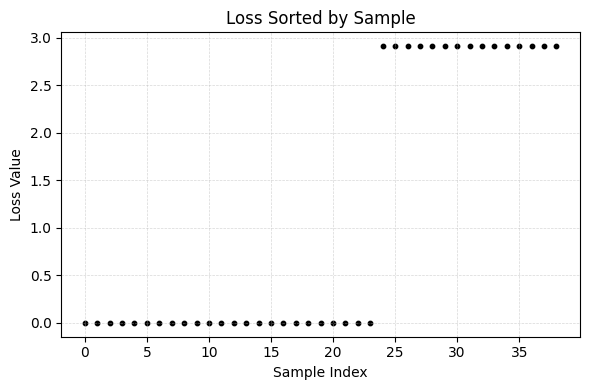

In [19]:
plot_sorted_loss(
    loss_finish,
    title="Loss Sorted by Sample",
    xlabel="Sample Index",
    ylabel="Loss Value",
)

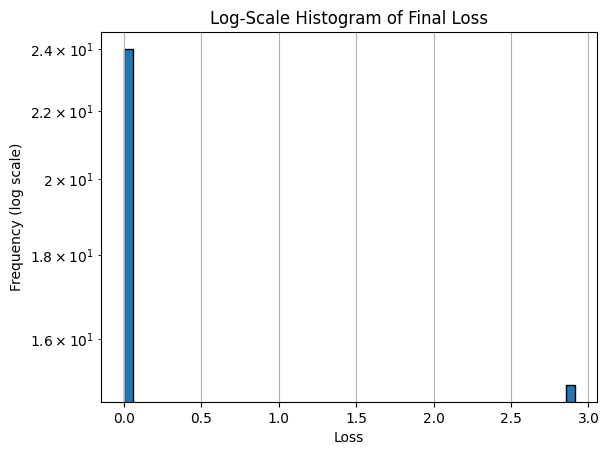

In [20]:
plt.hist(loss_finish, bins=50, edgecolor="black")
plt.yscale("log")
plt.title("Log-Scale Histogram of Final Loss")
plt.xlabel("Loss")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()

### PCA on flattened weight vectors

Each run's `(fc1, fc2)` weights, flattened into a single vector, projected
to 2D and 3D via PCA, colored by that run's final loss.

- Cluster around the origin: most networks converge to similar weights.
- Dark points: low final loss (network learned well).
- Light/red points: higher final loss (network failed), these still tend
  to land inside the main cluster, i.e. failed runs are not weight-space
  outliers.

In [21]:
pca_2d = PCA(n_components=2)
projected_2d = pca_2d.fit_transform(weights_finish)
plot_data(projected_2d.T, loss_finish)

In [22]:
pca_3d = PCA(n_components=3)
projected_3d = pca_3d.fit_transform(weights_finish)
plot_data(projected_3d.T, loss_finish)

### PCA on fc1 weights only (rows treated as separate points)

In [23]:
# Each network's fc1 has multiple rows; treat each row as its own point,
# colored by that network's final loss (repeated once per row).
fc1_rows = W1_finish.reshape(-1, W1_finish.shape[-1])
fc1_row_colors = np.repeat(loss_finish, W1_finish.shape[1])

pca_fc1 = PCA(n_components=3)
fc1_rows_3d = pca_fc1.fit_transform(fc1_rows)
plot_data(fc1_rows_3d.T, fc1_row_colors)

In [24]:
# Same fc1 rows, projected onto the unit sphere before PCA
fc1_rows_normalized = fc1_rows / np.linalg.norm(fc1_rows, axis=1, keepdims=True)
pca_fc1_sphere = PCA(n_components=3)
fc1_sphere_3d = pca_fc1_sphere.fit_transform(fc1_rows_normalized)
plot_data(fc1_sphere_3d.T, fc1_row_colors)

### Eigenvalues of $W_1 W_1^T$ for each run

In [25]:
W1_gram = W1_finish @ np.transpose(W1_finish, (0, 2, 1))  # shape (N_runs, hidden_dim, hidden_dim)
eigenvalues = np.linalg.eigvals(W1_gram)
eigenvalues_real = np.real(eigenvalues)
plot_data(eigenvalues_real.T, loss_finish)

### Single-run inspection

In [26]:
run_idx = min(24, len(W1_finish) - 1)  # 24 in the original notebook; clamped for small N
matrix = W1_finish[run_idx]
gram = matrix @ matrix.T
print(f"W1 for run {run_idx}:\n{matrix}")
print(f"Eigenvalues of W1 W1^T:\n{np.linalg.eigvals(gram)}")
print(f"Determinant of W1 W1^T: {np.linalg.det(gram)}")
print(f"Final loss for run {run_idx}: {loss_finish[run_idx]}")

W1 for run 24:
[[ 0.75890219 -0.14425759 -1.56565523]
 [ 0.79745108 -0.65783733 -0.44715151]
 [-1.25796437 -1.18466759  0.50060457]]
Eigenvalues of W1 W1^T:
[5.15425398 0.43545318 1.96345118]
Determinant of W1 W1^T: 4.40684107864913
Final loss for run 24: 4.654981369985045e-13


In [27]:
# Inspect every run whose final loss exceeds a threshold
LOSS_THRESHOLD = 23
for i in range(len(weights_finish)):
    if loss_finish[i] > LOSS_THRESHOLD:
        matrix = weights_finish[i].reshape(-1, 3)
        print(f"Run {i} (final loss {loss_finish[i]:.4f}):")
        print(matrix)
        print(f"Eigenvalues: {np.linalg.eigvals(matrix[0:3])}")
        print(f"Determinant: {np.linalg.det(matrix[0:3])}")
        print()